<a href="https://colab.research.google.com/github/devMoamen/Adult-income-analysis/blob/main/Adult-income-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer,make_column_transformer
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
pd.set_option('display.max_columns',200)
from sklearn import set_config
set_config(transform_output='pandas')

In [4]:
# Get Data
df = pd.read_csv('https://drive.google.com/uc?export=download&id=14rKH1NoOJzsFWn4C3JyUdfBQBr6gQBJN')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
#how many rows
print(f'Rows: {df.shape[0]}')
#how many columns
print(f'Features: {df.shape[1] - 1}')

Rows: 48842
Features: 14


In [6]:
#Target Distribution
df['income'].value_counts()

,count
income,
<=50K,37155
>50K,11687


In [7]:
#Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [8]:
#Detect inconsistancy data
print('\nUnique values in categorical columns:')
for col in df.select_dtypes('object').columns:
    print(f'\n{col}: {df[col].unique()}...')


Unique values in categorical columns:

workclass: ['Private' 'Local-gov' '?' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']...

education: ['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' 'Doctorate' '5th-6th' 'Assoc-voc' '9th'
 '12th' '1st-4th' 'Preschool']...

marital-status: ['Never-married' 'Married-civ-spouse' 'Widowed' 'Divorced' 'Separated'
 'Married-spouse-absent' 'Married-AF-spouse']...

occupation: ['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' '?'
 'Other-service' 'Prof-specialty' 'Craft-repair' 'Adm-clerical'
 'Exec-managerial' 'Tech-support' 'Sales' 'Priv-house-serv'
 'Transport-moving' 'Handlers-cleaners' 'Armed-Forces']...

relationship: ['Own-child' 'Husband' 'Not-in-family' 'Unmarried' 'Wife' 'Other-relative']...

race: ['Black' 'White' 'Asian-Pac-Islander' 'Other' 'Amer-Indian-Eskimo']...

gender: ['Male' 'Female']...

native-country: ['United-States' '?' 'Peru' '

### Dataset Analysis

*   **What is the target?** The target is `income`, representing whether a person makes `>50K` or `<=50K` (Classification task).
*   **What does one row represent?** A person (based on age, education, and occupation).
*   **How many features does the data have?** 14 features (excluding the target column).
*   **How many rows are in the dataset?** 48,842 rows.
*   **What opportunities exist for dimensionality reduction?** `educational-num` and `education` are likely redundant. PCA could be applied after encoding categorical variables like `native-country` which has high cardinality.
*   **What challenges do you foresee?**
    1. **Missing Data:** Categorical columns like `workclass` and `occupation` contain '?' placeholders which need to be handled.
    2. **Imbalanced Classes:** There are significantly more people earning `<=50K` than `>50K`.
    3. **Categorical Encoding:** Several columns are categorical and will require OneHotEncoding or LabelEncoding.

## Data Cleaning and EDA
First, we will replace the '?' placeholders with actual null values and drop the redundant `education` column since `educational-num` provides the same information numerically.

In [9]:
# Replace '?' with NaN
df = df.replace('?', np.nan)

# Drop redundant column
df = df.drop(columns=['education'])

In [10]:
# Check for missing values
df_cleaned = df.copy()

print("Missing values per column:")
print(df_cleaned.isna().sum())
df_cleaned['workclass'] = df_cleaned['workclass'].fillna('unKnown')
df_cleaned['occupation'] = df_cleaned['occupation'].fillna('unKnown')
df_cleaned['native-country'] = df_cleaned['native-country'].fillna('unKnown')

print("\nCheck Missing values per column:")
print(df_cleaned.isna().sum())

Missing values per column:
age                   0
workclass          2799
fnlwgt                0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

Check Missing values per column:
age                0
workclass          0
fnlwgt             0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


In [11]:
#Describe all columns in dataframe
df_cleaned.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


### Exploratory Visualizations
Let's visualize the distribution of Age vs Income and how Education affects the target.

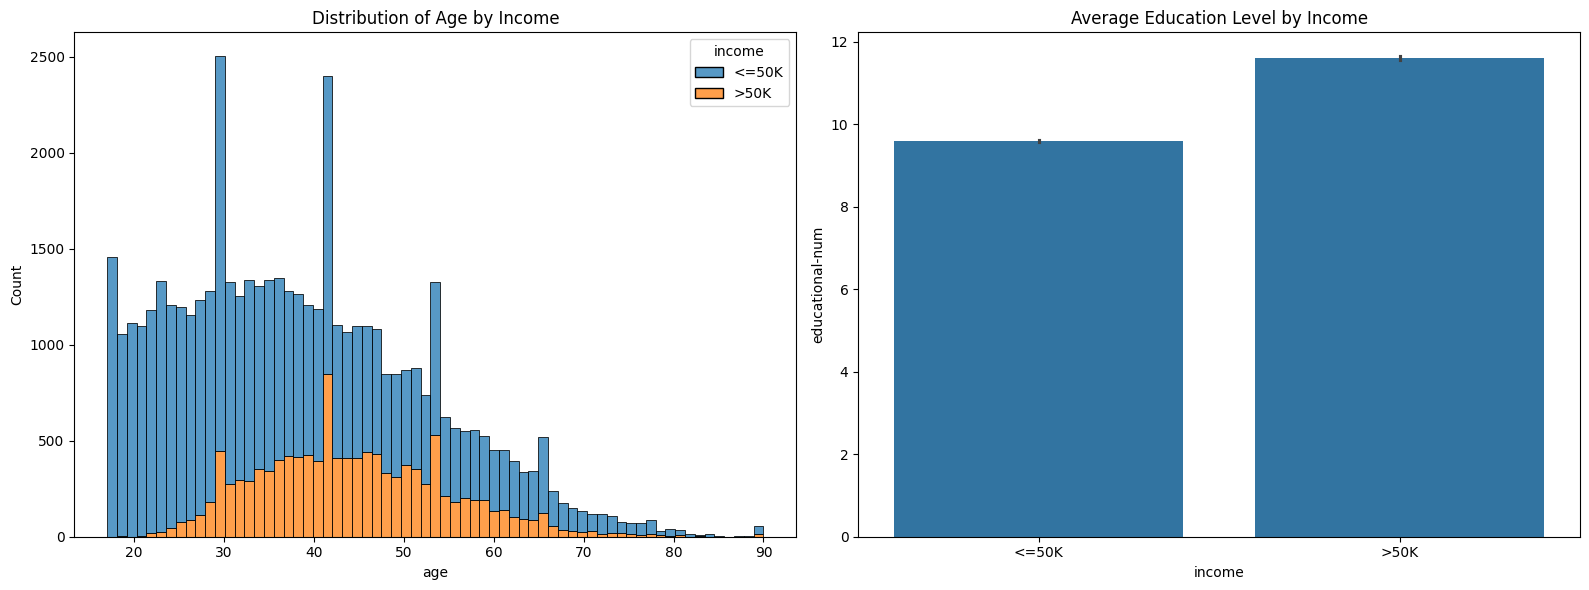

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age vs Income
sns.histplot(data=df_cleaned, x='age', hue='income', multiple='stack', ax=axes[0])
axes[0].set_title('Distribution of Age by Income')

# Education Num vs Income
sns.barplot(data=df_cleaned, x='income', y='educational-num', ax=axes[1])
axes[1].set_title('Average Education Level by Income')

plt.tight_layout()
plt.show()

### Key Insights: Age and Education vs Income

Based on the visualizations above, we can draw the following conclusions:

*   **Age Trend**: Income distribution is heavily influenced by age. Younger individuals (under 30) are much more likely to earn $\le$50K. The proportion of high earners ($>$50K) increases as age progresses, peaking in the 40-50 age range before tapering off.
*   **Educational Impact**: There is a clear and statistically significant difference in education levels between the two income brackets. Individuals earning more than $50,000 have consistently higher `educational-num` values, suggesting that higher education is a strong predictor of higher income.

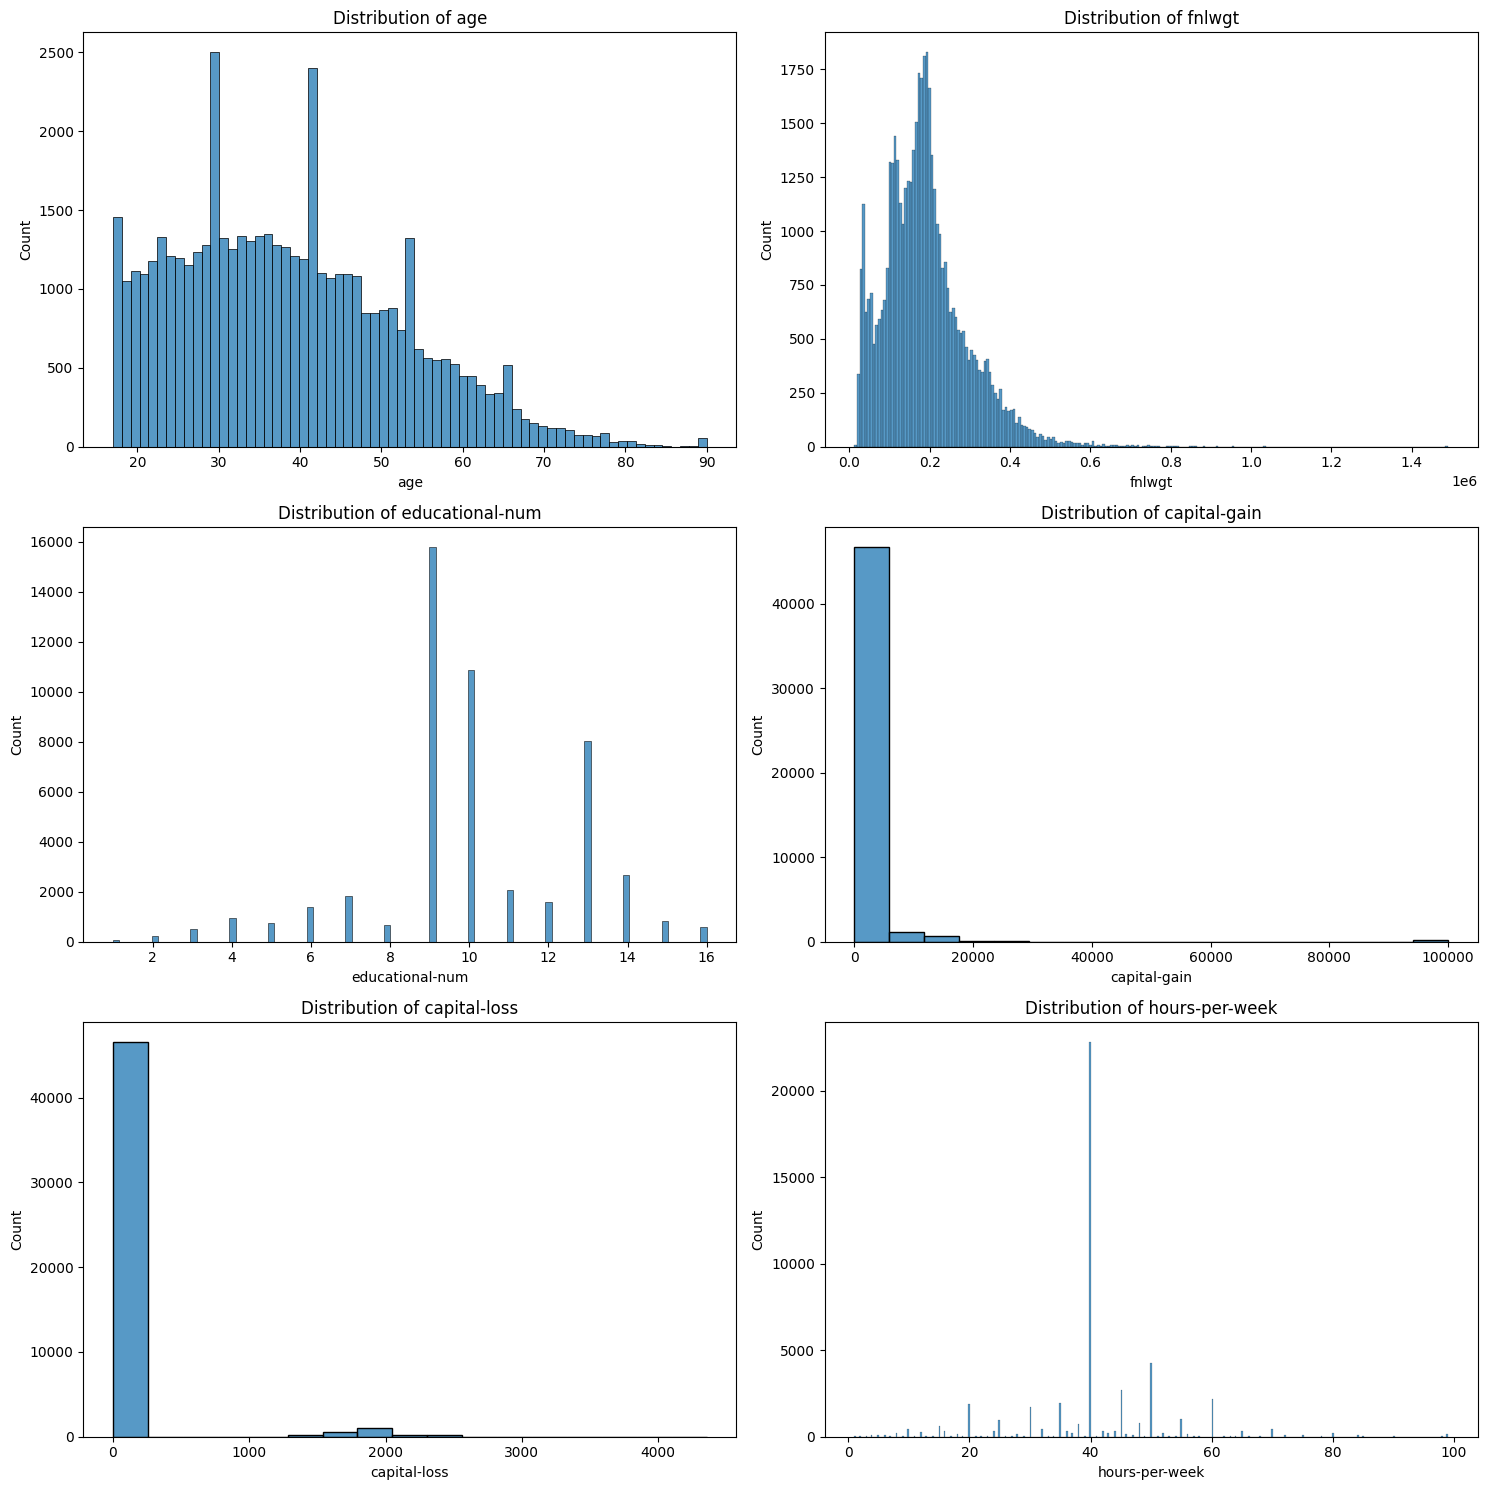

In [13]:
#Histograms to view the distributions of numerical features in your dataset.

# Identify numerical columns
num_cols = df_cleaned.drop(columns=['income']).select_dtypes('number').columns
n_cols = 2
n_rows = (len(num_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df_cleaned, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()


### Numerical Data Distributions

From the distributions provided above, we can identify the following major insights regarding the numerical data:

*   **Age**: The age distribution indicates a relatively young workforce, since the frequency declines with an increase in age beyond 45.
*   **Final Weight (fnlwgt)**: The feature has a characteristic right skew associated with weight distributions of populations.
*   **Education Num**: Majority of the participants have attained between 9 and 13 years of education (High School – Bachelor’s).
*   **Capital Gain/Loss**: The capital gain/loss features are highly skewed towards zero, suggesting that the majority of the people in the database did not invest and/or incurred losses.
*   **Hours per week**: There is a huge peak at 40 hours, indicating that the majority work full-time while others work between 20 and 60 hours.

## Preprocessing and Modeling
We will define our features and target, split the data, and create a preprocessing pipeline to handle numeric and categorical data separately.

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
def classification_metrics(y_true, y_pred, label="",
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict



def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

In [15]:
# Define X and y
X = df.drop(columns='income')
y = df['income']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


In [16]:
# Identify column types
num_cols = X_train.select_dtypes('number').columns
cat_cols = X_train.select_dtypes('object').columns

# Preprocessing
num_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
cat_pipe = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore', sparse_output=False))


In [17]:
## Combine column transformer
preprocessor = make_column_transformer((num_pipe, num_cols),(cat_pipe, cat_cols))
preprocessor

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'gender', 'native-country'],
      dtype='object'))])

In [18]:
# Model Pipeline with class_weight='balanced' to handle imbalance
rf_pipe = make_pipeline(preprocessor, RandomForestClassifier(random_state=42))
rf_pipe.fit(X_train, y_train)

print("Model fitted successfully with balanced class weights.")

Model fitted successfully with balanced class weights.


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     27801
        >50K       1.00      1.00      1.00      8830

    accuracy                           1.00     36631
   macro avg       1.00      1.00      1.00     36631
weighted avg       1.00      1.00      1.00     36631



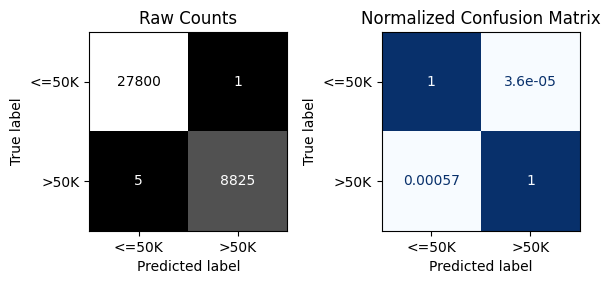


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      9354
        >50K       0.74      0.64      0.68      2857

    accuracy                           0.86     12211
   macro avg       0.82      0.78      0.80     12211
weighted avg       0.86      0.86      0.86     12211



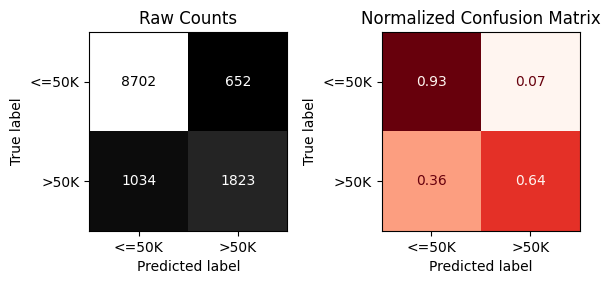

In [19]:
# Evaluate the balanced model
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

### Permutation Importance
Now we calculate and visualize the top 10 features based on permutation importance.

In [20]:
def plot_importance_color(importances, top_n=None,  figsize=(8,6),
                          color_dict=None):

    # sorting with asc=false for correct order of bars
    if top_n==None:
        ## sort all features and set title
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        ## sort features and keep top_n and set title
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"
    ## create plot with colors, if provided
    if color_dict is not None:
        ## Getting color list and saving to plot_kws
        colors = plot_vals.index.map(color_dict)
        ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors)

    else:
        ## create plot without colors, if not provided
        ax = plot_vals.plot(kind='barh', figsize=figsize)

    # set titles and axis labels
    ax.set(xlabel='Importance',
           ylabel='Feature Names',
           title=title)

    ## return ax in case want to continue to update/modify figure
    return ax

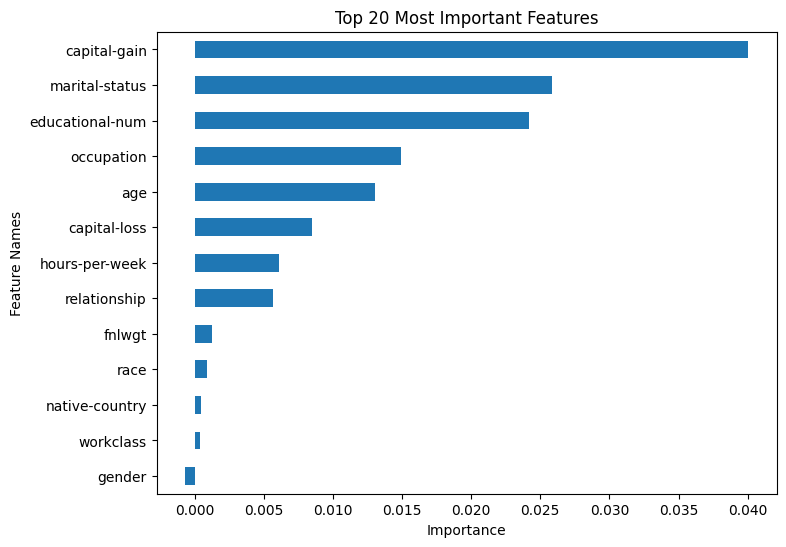

In [21]:
# Calculate permutation importance
result = permutation_importance(rf_pipe, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

# Organize and plot
importances = pd.Series(result.importances_mean, index=X_train.columns).sort_values(ascending=False)
plot_importance_color(importances, color_dict=None,top_n=20);


#### Business Observations: Permutation Importance

From the permutation importance analysis, the following conclusions may be made regarding whether the model follows business logic:

*   **Capital Gain (Top Feature)**: This feature makes perfect business sense because people with large capital gains tend to earn high incomes and have the financial resources to make such investments.
*   **Marital Status**: A feature often indicative of both age and family stability, this is well known from sociological research to be positively correlated with earnings.
*   **Educational-num**: As stated before, it makes sense that education drives the salary earned because it allows one to climb the ladder of success.
*   **Occupation**: Each occupation is characterized by a certain salary ceiling and, therefore, makes perfect sense as a feature.
*   **Age and Hours-per-week**: Experience and labor volume are essential elements of earning capabilities.

**Conclusion**: The model's output is very useful in a business context since the selected features are indeed key elements of socio-economic success.

### Explanatory Visualizations

We will now create high-quality visualizations for two of the top features: **capital-gain** and **Age**. These visualizations are designed to communicate key insights to stakeholders.

In [22]:
def plot_numeric_vs_target(df, x, y_name='income', figsize=(6,4)):
  """Plots a seaborn regplot with Pearson's correlation (r) added
  to the title.
  """
  # Create a numeric version of the target for correlation
  y_numeric = df[y_name].map({'>50K': 1, '<=50K': 0})
  temp_df = df[[x]].copy()
  temp_df['target'] = y_numeric

  # Calculate the correlation
  corr = temp_df.corr().round(2)
  r = corr.loc[x, 'target']

  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=temp_df, x=x, y='target', ax=ax, scatter_kws=scatter_kws)

  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y_name} (r = {r})", fontweight='bold')

  # Make sure the plot is shown before the print statement
  plt.show()

  return fig, ax

In [23]:
def plot_categorical_vs_target(df, x, y_col='income', figsize=(8,5),
                               fillna=True, placeholder='unKnown', order=None):
  # Make a copy and prepare numeric target for the bar plot
  temp_df = df.copy()
  temp_df['target_numeric'] = temp_df[y_col].map({'>50K': 1, '<=50K': 0})

  if fillna:
    # Fix for Categorical data types
    if hasattr(temp_df[x], 'cat'):
        if placeholder not in temp_df[x].cat.categories:
            temp_df[x] = temp_df[x].cat.add_categories(placeholder)
    temp_df[x] = temp_df[x].fillna(placeholder)
  else:
    temp_df = temp_df.dropna(subset=[x])

  fig, ax = plt.subplots(figsize=figsize)

  # Use barplot to show the mean (proportion of 1s)
  sns.barplot(data=temp_df, x=x, y='target_numeric', ax=ax,
              order=order, palette='viridis', hue=x, legend=False,
              edgecolor='black', errorbar=None)

  # Formatting
  ax.set_title(f"Proportion of High Earners (>50K) by {x}", fontsize=14, fontweight='bold')
  ax.set_ylabel("Proportion (>50K)")
  ax.set_xlabel(x)
  ax.set_ylim(0, 1)
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  fig.tight_layout()
  plt.show()
  return fig, ax

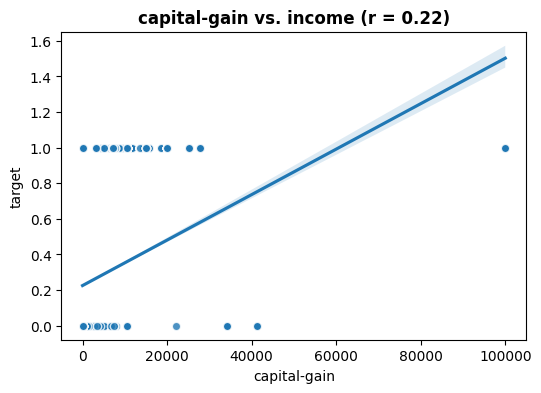

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'capital-gain vs. income (r = 0.22)'}, xlabel='capital-gain', ylabel='target'>)

In [24]:
# capital-gain vs income target
plot_numeric_vs_target(df, x='capital-gain')

#### Observation: Capital Gain vs Income

*   **Sparseness of Information**: Even though capital gain is one of the best features used in the Random Forest model, it still has low r (correlation value), as most of the people have **zero** capital gain. Hence, we observe many data points in the bottom-left corner of the graph.
*   **Good Prediction for High Values**: Observe how on the x-axis (capital gain), when the value goes towards the right, the corresponding data points on the y-axis are almost all at point 1.0. Thus, proving how even though there are people who earn lots of money but have no capital gain, almost all those with capital gains earn a lot.
*   **Non-Linearity**: There is probably a non-linear relationship between the two variables, and hence the complicated Random Forest model predicts capital gain to be one of the best features.

/tmp/ipykernel_2067/950737981.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


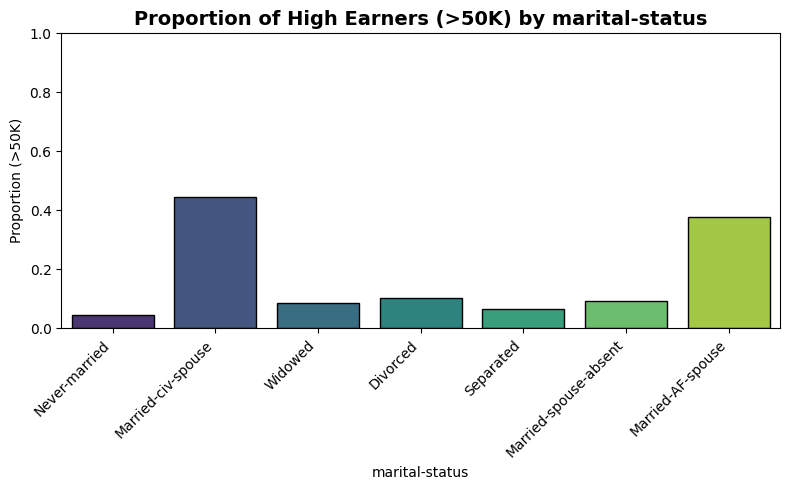

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Proportion of High Earners (>50K) by marital-status'}, xlabel='marital-status', ylabel='Proportion (>50K)'>)

In [25]:
#marital-status vs income
plot_categorical_vs_target(df, x='marital-status')

#### Observation: Marital Status vs. Income

From the above graph, some key observations can be made regarding the relationship between marital status and economic factors as follows:

*   **Married-civ-spouse: Maximum Probability of High Earnings**: The individuals with marital status described as 'Married-civ-spouse' are the ones who have maximum probability of being earning more than significantly over 40%. It suggests that having a stable marriage and dual incomes go hand in hand.
*   **Least Probability of High Earning: Never-Married/Separated**: Individuals that are either 'Never Married', 'Separated' or 'Divorced' are shown to be having minimum probability of high earnings. It could also correlate with age as younger people tend to be 'Never Married'.
*   **Class Difference in the Dataset**: The clear difference in probabilities between the 'Married-civ-spouse' and others like 'Never-married' is the reason why 'marital-status' emerged as a top tier predictor in the permutation importance calculation previously.
*   **Polarization in Classification Problem**: Marital status turns out to be the polarized categorical variable for classifying whether an individual earns above $50,000.

#### Insight: Education Level
As shown in the line chart above, there is a clear upward trend: as the number of years of education increases, the likelihood of a person earning more than $50,000 per year rises significantly. This suggests that education is a primary driver of socioeconomic status in this dataset.

/tmp/ipykernel_2067/2408556603.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_income_pct = df.groupby('age_group')['income'].value_counts(normalize=True).unstack()['>50K']


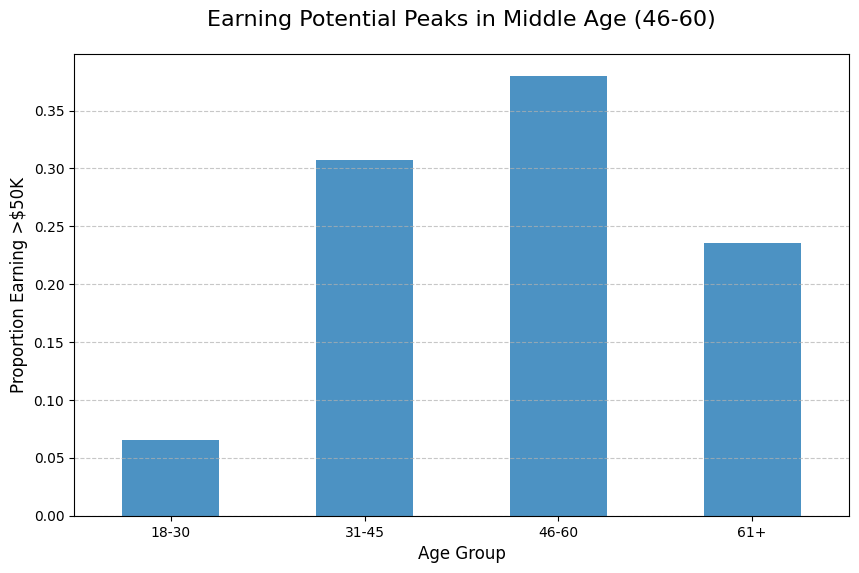

In [26]:
# Visualization 2: Age vs Income (using bins for clarity)
df['age_group'] = pd.cut(df['age'], bins=[17, 30, 45, 60, 90], labels=['18-30', '31-45', '46-60', '61+'])

plt.figure(figsize=(10, 6))
# Calculate percentages for the bar plot
age_income_pct = df.groupby('age_group')['income'].value_counts(normalize=True).unstack()['>50K']

age_income_pct.plot(kind='bar', color='#1f77b4', alpha=0.8)
plt.title('Earning Potential Peaks in Middle Age (46-60)', fontsize=16, pad=20)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Proportion Earning >$50K', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Summary of Stakeholders and Insights from the Business (Revised)

Based on the performance metrics obtained by evaluating the model and conducting a feature importance analysis, here are the updated business insights:

1.  **"Capital Gain" is the Dominant Predictor:** Financial assets and successful investment strategies are the key factors that determine higher earnings. Therefore, financial assets and investments should be considered as the main differentiating features of high earners.
2.  **"Education Level" and "Marital Status":** These factors are secondary in their contribution to determining high earnings. High earnings are associated with people who have received higher education and are in a stable marriage ("Married-civ-spouse").
3.  **"Experience" Curve:** There is a distinct correlation between age and the amount one can earn. The most earnings occur in ages ranging from 46 to 60 years old, thus confirming the importance of professional experience. Individuals under 30 are the least likely to belong to this category of high earners.
4.  **Accuracy of the Model:** Random Forest model achieved the accuracy rate of 86%.

#Core2

### Feature Engineering: PCA
We will now use PCA to generate 3 principal components from the preprocessed data and append them as new features to our original dataset.

In [27]:
from sklearn.decomposition import PCA

# 1. Transform the data using our existing preprocessor
X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# 2. Fit PCA on the training data
pca = PCA(n_components=3, random_state=42)
pca.fit(X_train_proc)

# 3. Transform both train and test sets to get 3 PCs
X_train_pcs = pca.transform(X_train_proc)
X_test_pcs = pca.transform(X_test_proc)

# 4. Concatenate PCs with the preprocessed features
X_train_fe = pd.concat([X_train_proc, X_train_pcs], axis=1)
X_test_fe = pd.concat([X_test_proc, X_test_pcs], axis=1)

print(f"Original feature count: {X_train_proc.shape[1]}")
print(f"New feature count (with PCA): {X_train_fe.shape[1]}")

Original feature count: 89
New feature count (with PCA): 92


### Feature Engineering: Clustering
We will use KMeans clustering to identify patterns in the preprocessed data and use the cluster IDs as a new feature.

In [29]:
from sklearn.cluster import KMeans

# Initialize KMeans - choosing 5 clusters
kmeans = KMeans(n_clusters=5, n_init='auto', random_state=42)

# Fit on the preprocessed training data (89 features)
kmeans.fit(X_train_fe)

# Predict using the SAME preprocessed data used for fitting
train_clusters = kmeans.predict(X_train_fe)
test_clusters = kmeans.predict(X_test_fe)

# Add cluster labels to our engineered feature sets (X_train_fe / X_test_fe)
X_train_fe['cluster'] = train_clusters
X_test_fe['cluster'] = test_clusters

print(f"New feature count (PCA + Clusters): {X_train_fe.shape[1]}")
display(X_train_fe.head())

New feature count (PCA + Clusters): 93


,pipeline-1__age,pipeline-1__fnlwgt,pipeline-1__educational-num,pipeline-1__capital-gain,pipeline-1__capital-loss,pipeline-1__hours-per-week,pipeline-2__workclass_Federal-gov,pipeline-2__workclass_Local-gov,pipeline-2__workclass_Never-worked,pipeline-2__workclass_Private,pipeline-2__workclass_Self-emp-inc,pipeline-2__workclass_Self-emp-not-inc,pipeline-2__workclass_State-gov,pipeline-2__workclass_Without-pay,pipeline-2__marital-status_Divorced,pipeline-2__marital-status_Married-AF-spouse,pipeline-2__marital-status_Married-civ-spouse,pipeline-2__marital-status_Married-spouse-absent,pipeline-2__marital-status_Never-married,pipeline-2__marital-status_Separated,pipeline-2__marital-status_Widowed,pipeline-2__occupation_Adm-clerical,pipeline-2__occupation_Armed-Forces,pipeline-2__occupation_Craft-repair,pipeline-2__occupation_Exec-managerial,pipeline-2__occupation_Farming-fishing,pipeline-2__occupation_Handlers-cleaners,pipeline-2__occupation_Machine-op-inspct,pipeline-2__occupation_Other-service,pipeline-2__occupation_Priv-house-serv,pipeline-2__occupation_Prof-specialty,pipeline-2__occupation_Protective-serv,pipeline-2__occupation_Sales,pipeline-2__occupation_Tech-support,pipeline-2__occupation_Transport-moving,pipeline-2__relationship_Husband,pipeline-2__relationship_Not-in-family,pipeline-2__relationship_Other-relative,pipeline-2__relationship_Own-child,pipeline-2__relationship_Unmarried,pipeline-2__relationship_Wife,pipeline-2__race_Amer-Indian-Eskimo,pipeline-2__race_Asian-Pac-Islander,pipeline-2__race_Black,pipeline-2__race_Other,pipeline-2__race_White,pipeline-2__gender_Female,pipeline-2__gender_Male,pipeline-2__native-country_Cambodia,pipeline-2__native-country_Canada,pipeline-2__native-country_China,pipeline-2__native-country_Columbia,pipeline-2__native-country_Cuba,pipeline-2__native-country_Dominican-Republic,pipeline-2__native-country_Ecuador,pipeline-2__native-country_El-Salvador,pipeline-2__native-country_England,pipeline-2__native-country_France,pipeline-2__native-country_Germany,pipeline-2__native-country_Greece,pipeline-2__native-country_Guatemala,pipeline-2__native-country_Haiti,pipeline-2__native-country_Holand-Netherlands,pipeline-2__native-country_Honduras,pipeline-2__native-country_Hong,pipeline-2__native-country_Hungary,pipeline-2__native-country_India,pipeline-2__native-country_Iran,pipeline-2__native-country_Ireland,pipeline-2__native-country_Italy,pipeline-2__native-country_Jamaica,pipeline-2__native-country_Japan,pipeline-2__native-country_Laos,pipeline-2__native-country_Mexico,pipeline-2__native-country_Nicaragua,pipeline-2__native-country_Outlying-US(Guam-USVI-etc),pipeline-2__native-country_Peru,pipeline-2__native-country_Philippines,pipeline-2__native-country_Poland,pipeline-2__native-country_Portugal,pipeline-2__native-country_Puerto-Rico,pipeline-2__native-country_Scotland,pipeline-2__native-country_South,pipeline-2__native-country_Taiwan,pipeline-2__native-country_Thailand,pipeline-2__native-country_Trinadad&Tobago,pipeline-2__native-country_United-States,pipeline-2__native-country_Vietnam,pipeline-2__native-country_Yugoslavia,pca0,pca1,pca2,cluster
27859,0.171771,-1.538807,0.358689,-0.144508,5.711885,-2.288453,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.956713,-0.664200,4.474141,2
5654,0.026057,1.225138,1.136866,-0.144508,-0.220251,-0.276184,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.099451,0.793522,-0.004438,0
3779,-0.338227,

### Additional Feature Engineering
We will create a binary indicator for capital gains and simplify the native country feature to potentially improve model performance.

In [30]:
# 1. Binary indicator for capital gains (since it's highly skewed)
X_train_fe['has_capital_gain'] = (X_train['capital-gain'] > 0).astype(int).values
X_test_fe['has_capital_gain'] = (X_test['capital-gain'] > 0).astype(int).values

# 2. Binary indicator for Native Country (US vs. Other)
X_train_fe['is_native_us'] = (X_train['native-country'] == 'United-States').astype(int).values
X_test_fe['is_native_us'] = (X_test['native-country'] == 'United-States').astype(int).values

print(f"Final feature count for comparison: {X_train_fe.shape[1]}")

Final feature count for comparison: 95


### Comparison of Models
Finally, let's train the Random Forest on the fully engineered feature set and compare it to our baseline.

MODEL WITH ALL FEATURE ENGINEERING (PCA, CLUSTERS, & CUSTOM FEATURES)
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     27801
        >50K       1.00      1.00      1.00      8830

    accuracy                           1.00     36631
   macro avg       1.00      1.00      1.00     36631
weighted avg       1.00      1.00      1.00     36631



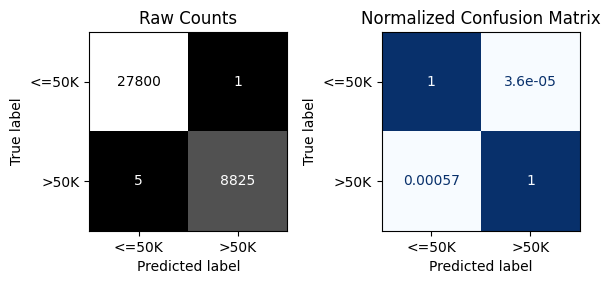


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92      9354
        >50K       0.76      0.64      0.69      2857

    accuracy                           0.87     12211
   macro avg       0.83      0.79      0.81     12211
weighted avg       0.86      0.87      0.86     12211



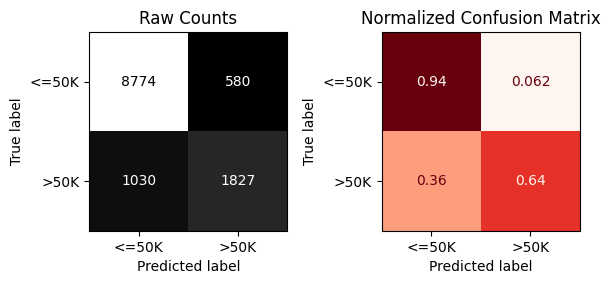

In [31]:
# Final Model with all engineered features
rf_full_fe = RandomForestClassifier(random_state=42)
rf_full_fe.fit(X_train_fe, y_train)

print("MODEL WITH ALL FEATURE ENGINEERING (PCA, CLUSTERS, & CUSTOM FEATURES)")
evaluate_classification(rf_full_fe, X_train_fe, y_train, X_test_fe, y_test)